In [51]:
import pylab as plt
import numpy as np
import astropy.units as u
from astropy.io import ascii

from PyAstronomy.pyasl import planck
from astropy.modeling import models

## Calculate the dust disk mass and total disk mass via the standard relation from Hillebrand+1983
### Mdust = (d^2 * F_cont)/(kappa_nu * Planck(Tc))
### Mtot = 100*Mdust

In [48]:
def dust_disk_mass(dist, F_nu, wavelength, Tc):
    """
    d in pc
    F_nu in mJy
    wavelength in mm
    Tc in Kelvin
    """
    d = dist*u.pc
    F_nu = (F_nu/1000)*u.Jy
    kappa_nu = 2.3*u.cm**2./u.g
    Tc = Tc*u.K
    bb_Planck = models.BlackBody(temperature=Tc)
    bb_wav = (wavelength*u.mm).to(u.cm)
    
    return (d**2.*F_nu)/(kappa_nu*bb_Planck(bb_wav))

In [96]:
Mdust = dust_disk_mass(dist=180., F_nu=44., wavelength=1.3, Tc=20.)
Mdust.cgs

<Quantity 2.41215733e+29 rad2 g>

In [97]:
### dust disk mass
Mdust_converted = (Mdust.cgs.value)*u.g
Mdisk_dust = Mdust_converted.cgs.to(u.Mearth)
Mdisk_dust

<Quantity 40.38997874 earthMass>

In [98]:
### gas disk mass 
Mdisk_total = Mdisk_dust*100.
Mdisk_total.to(u.Mjup)

<Quantity 12.7081085 jupiterMass>

In [49]:
Mdisk_total.to(u.Msun)

<Quantity 0.05125759 solMass>

### Plot DraChi over figure 3 from Wyatt 2008

In [55]:
A_stars = ascii.read('/Users/kristina/Hamburgers/Draculas_Chivito/Wyatt2008_Figure3/A-stars.csv', delimiter=',')
FGK_stars = ascii.read('/Users/kristina/Hamburgers/Draculas_Chivito/Wyatt2008_Figure3/FGK-stars.csv', delimiter=',')
M_stars = ascii.read('/Users/kristina/Hamburgers/Draculas_Chivito/Wyatt2008_Figure3/M-stars.csv', delimiter=',')


Text(0.5, 1.0, 'Wyatt (2008)')

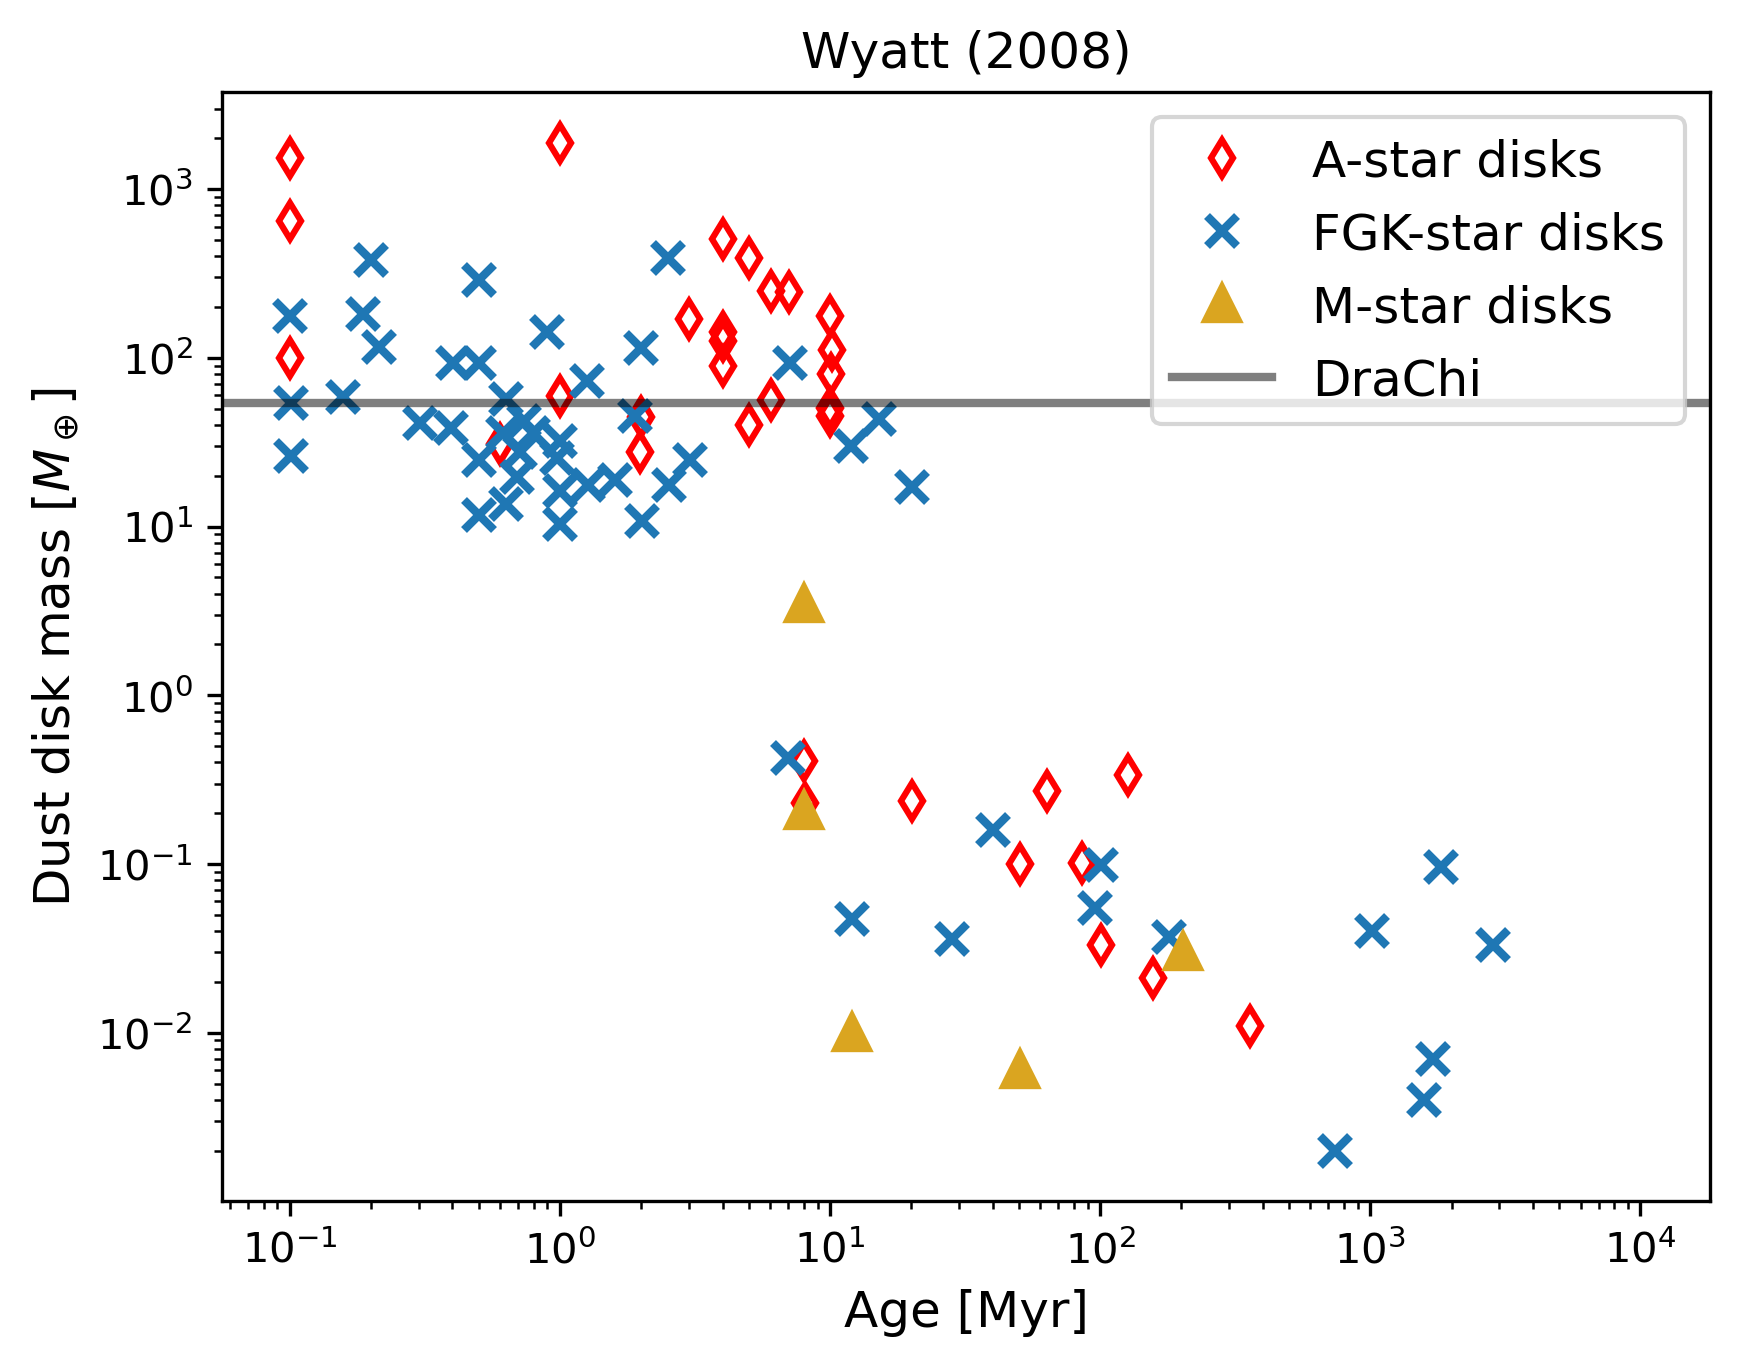

In [95]:
plt.figure(dpi=300)

plt.plot(A_stars['col1'], A_stars['col2'], 'd', markeredgecolor='red', markerfacecolor='none', markeredgewidth=1.5, label='A-star disks')
plt.plot(FGK_stars['col1'], FGK_stars['col2'], 'x', markersize=7, markeredgewidth=2, c='C0', label='FGK-star disks')
plt.plot(M_stars['col1'], M_stars['col2'], '^', markersize=7, markeredgewidth=2, c='goldenrod', label='M-star disks')

plt.axhline(54, c='black', label='DraChi', lw=2, alpha=0.5)


plt.loglog()
plt.xlabel('Age [Myr]', fontsize=12)
plt.ylabel(r'Dust disk mass [$M_\oplus$]', fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.title('Wyatt (2008)')